# Importing Data

In [1]:
#This gets us into the right directory from home, in order to run the import python script from Mat

#sys = system (module), gives information and control over python interpreter/terminal itself
import sys
sys.path.append("/home/565/pv3484/aus_substation_electricity")

#% is a magic command, special shortcut command that lets you control/interact with notebook environment (ie. gives control of terminal without writing full python code)
%cd /home/565/pv3484/aus_substation_electricity

!pwd

/home/565/pv3484/aus_substation_electricity
/home/565/pv3484/aus_substation_electricity


In [2]:
#This section imports the substations that Mat put together

%run /home/565/pv3484/aus_substation_electricity/import_substation.py

processing nsw substations for ['ausgrid'] from None to None
ausgrid
following columns in demand are not in info index:
['MT_HU', 'SI_NO']
removing these columns from demand
number of substations in ausgrid substation info: 134
number of substations in ausgrid substation data: 132
following sites match selection criteria:
               energy_asset          Name  Area  Dwellings  Persons  Residential  Commercial  Industrial  Primary Production  Education  \
ID                                                                                                                                        
BLAKE         AG_BLAKEHURST    Blakehurst     7      10081    28521        0.850       0.005       0.021               0.000      0.022   
PUNCH          AG_PUNCHBOWL     Punchbowl     9      17514    50395        0.826       0.048       0.038               0.000      0.025   
MEADO         AG_MEADOWBANK    Meadowbank    15      22420    56948        0.825       0.023       0.015               0

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np
import matplotlib
from matplotlib.colors import ListedColormap

## Holiday Function

In [4]:
import pandas as pd
from datetime import date, timedelta
from dateutil.easter import easter

#Monarch's Birthday
def second_monday_of_june(y):
    """Return the date of the second Monday in June for year y."""
    june = pd.date_range(start=f"{y}-06-01", end=f"{y}-06-30", freq="D")
    mondays = june[june.weekday == 0]   # Monday = 0
    return mondays[1]                   # second Monday



# Define all national public holidays (including moving ones like Easter)
HOLIDAYS_VIC = {
    "New Year's Day": lambda y: pd.Timestamp(f"{y}-01-01"),
    "Australia Day": lambda y: pd.Timestamp(f"{y}-01-26"),
    "Good Friday": lambda y: pd.Timestamp(easter(y)) - pd.Timedelta(days=2),
    "Easter Saturday": lambda y: pd.Timestamp(easter(y)) - pd.Timedelta(days=1),
    "Easter Sunday": lambda y: pd.Timestamp(easter(y)),
    "Easter Monday": lambda y: pd.Timestamp(easter(y)) + pd.Timedelta(days=1),
    "ANZAC Day": lambda y: pd.Timestamp(f"{y}-04-25"),
    "Queen's Birthday": lambda y: second_monday_of_june(y),
    "Christmas Day": lambda y: pd.Timestamp(f"{y}-12-25"),
    "Boxing Day": lambda y: pd.Timestamp(f"{y}-12-26"),
}

holiday_order = list(HOLIDAYS_VIC.keys())

## CSV files

In [5]:
import pandas as pd

demand_rank = pd.read_csv("/home/565/pv3484/aus_substation_electricity/data/cleaned_data/full_nsw_relative_rank.csv")

weather_rank = pd.read_csv("/home/565/pv3484/aus_substation_electricity/data/BOM_NSW_weather_processed_v3/weather_holiday_block_means_with_codes.csv")

In [6]:
#replacing Monarch's Birthday with Queen's Birthday (same day, not change in data, just title change)

demand_rank["holiday_group"] = demand_rank["holiday_group"].replace({
    "Monarch's Birthday": "Queen's Birthday"
})

weather_rank["holiday_group"] = weather_rank["holiday_group"].replace({
    "Monarch's Birthday": "Queen's Birthday"
})


In [7]:
weather_rank.columns.tolist()

['date',
 '00_04_temp',
 '04_10_temp',
 '10_15_temp',
 '15_20_temp',
 '20_24_temp',
 '00_04_dewpoint',
 '04_10_dewpoint',
 '10_15_dewpoint',
 '15_20_dewpoint',
 '20_24_dewpoint',
 '00_04_relative_humidity',
 '04_10_relative_humidity',
 '10_15_relative_humidity',
 '15_20_relative_humidity',
 '20_24_relative_humidity',
 '00_04_wind_speed_kmh',
 '04_10_wind_speed_kmh',
 '10_15_wind_speed_kmh',
 '15_20_wind_speed_kmh',
 '20_24_wind_speed_kmh',
 '00_04_precip_incremental',
 '04_10_precip_incremental',
 '10_15_precip_incremental',
 '15_20_precip_incremental',
 '20_24_precip_incremental',
 'weekday_name',
 'is_weekend',
 'station_id',
 'station_name_x',
 'lat',
 'lon',
 'year',
 'holiday',
 'holiday_group',
 'is_holiday',
 'nearest_station_id',
 'name',
 'station_name_y',
 'station_code']

# MRR vs relative humidity
- rather than temperature and coloured dots by dewpoint

In [8]:
def plot_rh_scatter_for_station(
    demand_rank,
    weather_rank,
    station_code,
    holiday_name,
    time_blocks=None
):
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

    if time_blocks is None:
        time_blocks = ["00_04", "04_10", "10_15", "15_20", "20_24"]

    df_d = demand_rank[
        (demand_rank["station_code"] == station_code) &
        (demand_rank["holiday_group"] == holiday_name)
    ].copy()
    if df_d.empty:
        return None, ["NO DEMAND DATA"]

    df_w = weather_rank[
        (weather_rank["holiday_group"] == holiday_name) &
        (weather_rank["station_code"] == station_code)
    ].copy()
    if df_w.empty:
        return None, ["NO WEATHER DATA"]

    merged = pd.merge(
        df_d, df_w,
        on=["date", "holiday_group", "station_code"],
        how="inner",
        suffixes=("", "_w")
    )
    if merged.empty:
        return None, ["NO MERGED DATA"]

    merged["is_weekend"] = merged.get("is_weekend", merged.get("is_weekend_w"))
    merged["is_holiday"] = merged.get("is_holiday", merged.get("is_holiday_w"))
    merged["year"] = pd.to_datetime(merged["date"]).dt.year

    full_station_name = merged["Name"].iloc[0] if "Name" in merged.columns else station_code

    # --- Discrete year colours ---
    years = sorted(merged["year"].unique())
    year_palette = plt.cm.tab20.colors  # up to 20 distinct colours
    year_color_map = {yr: year_palette[i % len(year_palette)] for i, yr in enumerate(years)}

    weekday_color = "#D8D8D8"
    weekend_color = "skyblue"

    block_titles = ["12am–4am", "4am–10am", "10am–3pm", "3pm–8pm", "8pm–12am"]

    fig, axes = plt.subplots(
        1, len(time_blocks),
        figsize=(4.5 * len(time_blocks), 5.0),
        sharey=False
    )

    for col_idx, block in enumerate(time_blocks):
        ax = axes[col_idx]

        rank_col = f"{block}_mean_relative_rank"
        rh_col = f"{block}_relative_humidity"

        ax.set_title(block_titles[col_idx], fontsize=14, pad=10)

        if rank_col not in merged.columns or rh_col not in merged.columns or merged[rh_col].isna().all():
            ax.set_visible(False)
            continue

        # Weekday background
        wd = merged[~merged["is_weekend"]]
        ax.scatter(wd[rh_col], wd[rank_col], color=weekday_color, alpha=0.35, s=35, zorder=1)

        # Weekend background
        we = merged[merged["is_weekend"]]
        ax.scatter(we[rh_col], we[rank_col], color=weekend_color, alpha=0.45, s=35, zorder=1)

        # Holiday dots coloured by year
        holiday_rows = merged[merged["is_holiday"]].copy()
        colors = [year_color_map[yr] for yr in holiday_rows["year"]]

        ax.scatter(
            holiday_rows[rh_col], holiday_rows[rank_col],
            c=colors, s=120, edgecolor="black", linewidth=0.7, zorder=2
        )

        ax.set_xlabel("Relative Humidity (%)", fontsize=13)
        if col_idx == 0:
            ax.set_ylabel("Mean Relative Rank", fontsize=13)
        else:
            ax.set_ylabel("")
            ax.tick_params(axis='y', labelleft=False)

        ax.tick_params(axis='both', labelsize=10)
        ax.margins(0.05)

    fig.suptitle(
        f"{holiday_name} — {full_station_name}\n"
        f"Relative Humidity vs Mean Relative Rank  |  Holiday coloured by Year",
        fontsize=16, y=1.05, linespacing=1.3
    )

    # --- Day type legend ---
    weekday_handle = plt.Line2D([], [], marker="o", linestyle="", color=weekday_color,
                                markersize=8, label="Weekday")
    weekend_handle = plt.Line2D([], [], marker="o", linestyle="", color=weekend_color,
                                markersize=8, label="Weekend")

    fig.legend(
        handles=[weekday_handle, weekend_handle],
        title="Day Type", title_fontsize=12, fontsize=12,
        loc="center",
        bbox_to_anchor=(0.25, 0.02),
        borderpad=0.4, labelspacing=0.3, handletextpad=0.4,
        ncol=1,
        frameon=True
    )

    # --- Year legend ---
    year_handles = [
        mpatches.Patch(color=year_color_map[yr], label=str(yr))
        for yr in years
    ]

    fig.legend(
        handles=year_handles,
        title="Year", title_fontsize=12, fontsize=12,
        loc="center",
        bbox_to_anchor=(0.5, 0.02),
        borderpad=0.4, labelspacing=0.3, handletextpad=0.4,
        ncol=min(len(years), 7),
        frameon=True
    )

    fig.subplots_adjust(top=0.86, bottom=0.22, left=0.07, right=0.98, wspace=0.18)

    return fig, []

(<Figure size 2250x500 with 5 Axes>, [])

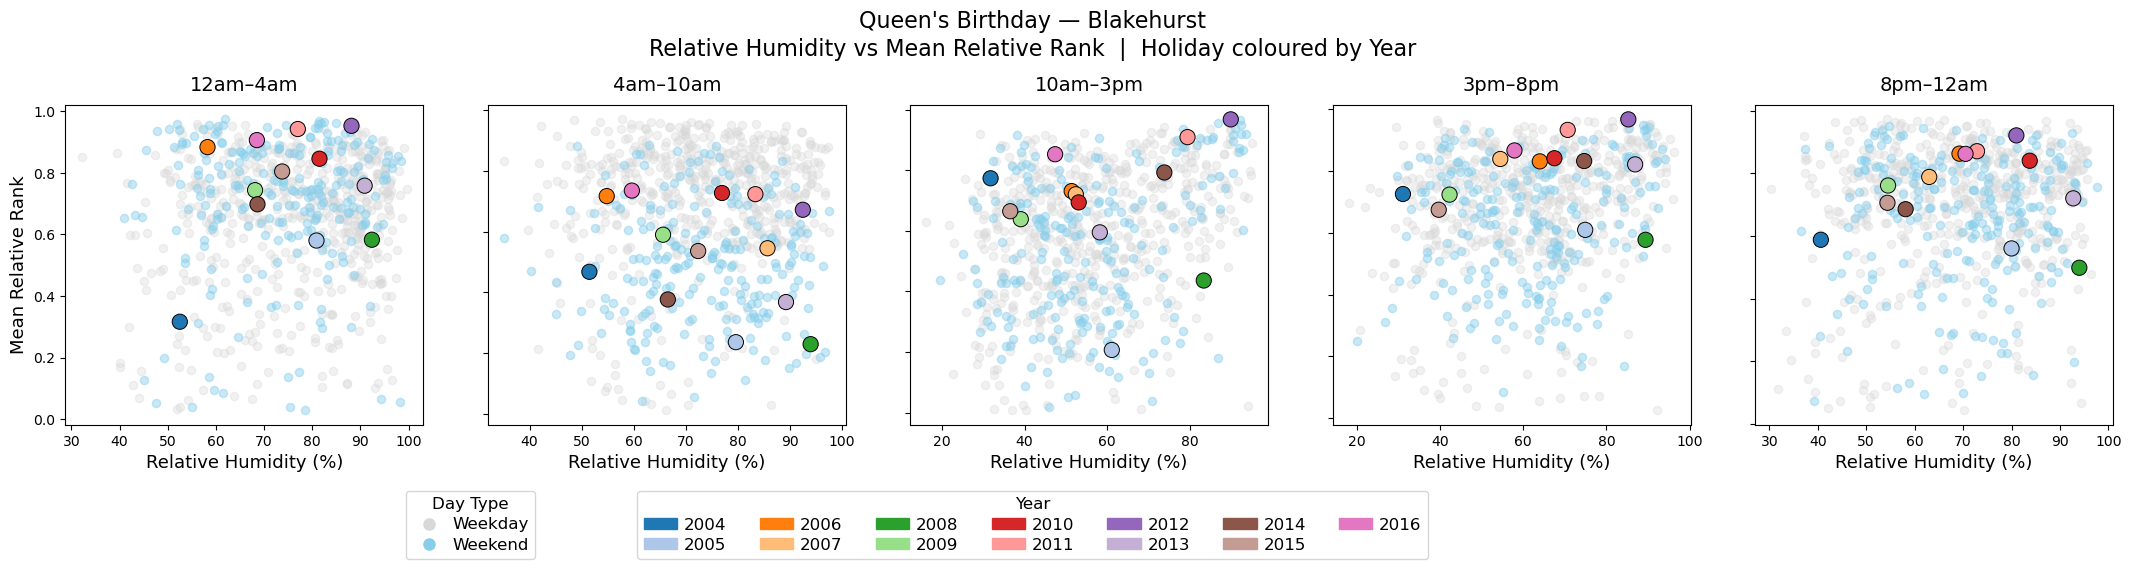

In [9]:
plot_rh_scatter_for_station(
    demand_rank,
    weather_rank,
    "BLAKE",
    "Queen's Birthday"
)

# Relative Humidity as the coloured dots (continuous)

In [41]:
def plot_rh_scatter_for_station(
    demand_rank,
    weather_rank,
    station_code,
    holiday_name,
    time_blocks=None
):
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.colors import Normalize
    from matplotlib.cm import ScalarMappable

    if time_blocks is None:
        time_blocks = ["00_04", "04_10", "10_15", "15_20", "20_24"]

    df_d = demand_rank[
        (demand_rank["station_code"] == station_code) &
        (demand_rank["holiday_group"] == holiday_name)
    ].copy()
    if df_d.empty:
        return None, ["NO DEMAND DATA"]

    df_w = weather_rank[
        (weather_rank["holiday_group"] == holiday_name) &
        (weather_rank["station_code"] == station_code)
    ].copy()
    if df_w.empty:
        return None, ["NO WEATHER DATA"]

    merged = pd.merge(
        df_d, df_w,
        on=["date", "holiday_group", "station_code"],
        how="inner",
        suffixes=("", "_w")
    )
    if merged.empty:
        return None, ["NO MERGED DATA"]

    merged["is_weekend"] = merged.get("is_weekend", merged.get("is_weekend_w"))
    merged["is_holiday"] = merged.get("is_holiday", merged.get("is_holiday_w"))

    full_station_name = merged["Name"].iloc[0] if "Name" in merged.columns else station_code

    weekday_color = "#D8D8D8"
    weekend_color = "skyblue"

    # Global relative humidity range across all blocks
    rh_cols = [f"{block}_relative_humidity" for block in time_blocks if f"{block}_relative_humidity" in merged.columns]
    holiday_rows_all = merged[merged["is_holiday"]]

    if rh_cols:
        global_rh_min = holiday_rows_all[rh_cols].min().min()
        global_rh_max = holiday_rows_all[rh_cols].max().max()
        if global_rh_min == global_rh_max:
            global_rh_min -= 0.5
            global_rh_max += 0.5
    else:
        global_rh_min, global_rh_max = 0, 1

    rh_cmap = plt.cm.RdYlGn  # red (low RH) to blue (high RH)
    rh_norm = Normalize(vmin=0, vmax=100)

    block_titles = ["12am–4am", "4am–10am", "10am–3pm", "3pm–8pm", "8pm–12am"]

    fig, axes = plt.subplots(
        1, len(time_blocks),
        figsize=(4.5 * len(time_blocks), 5.0),
        sharey=False
    )

    for col_idx, block in enumerate(time_blocks):
        ax = axes[col_idx]

        rank_col = f"{block}_mean_relative_rank"
        x_col = f"{block}_temp"
        rh_col = f"{block}_relative_humidity"

        ax.set_title(block_titles[col_idx], fontsize=14, pad=10)

        if rank_col not in merged.columns or x_col not in merged.columns or merged[x_col].isna().all():
            ax.set_visible(False)
            continue

        # Weekday background
        wd = merged[~merged["is_weekend"]]
        ax.scatter(wd[x_col], wd[rank_col], color=weekday_color, alpha=0.35, s=35, zorder=1)

        # Weekend background
        we = merged[merged["is_weekend"]]
        ax.scatter(we[x_col], we[rank_col], color=weekend_color, alpha=0.45, s=35, zorder=1)

        # Holiday dots coloured by dewpoint
        holiday_rows = merged[merged["is_holiday"]].copy()

        if rh_col in merged.columns and not holiday_rows[rh_col].isna().all():
            colors = rh_cmap(rh_norm(holiday_rows[rh_col].values))
        else:
            colors = ["#AAAAAA"] * len(holiday_rows)

        ax.scatter(
            holiday_rows[x_col], holiday_rows[rank_col],
            c=colors, s=120, edgecolor="black", linewidth=0.7, zorder=2
        )

        ax.set_xlabel("Temperature (°C)", fontsize=13)
        if col_idx == 0:
            ax.set_ylabel("Mean Relative Rank", fontsize=13)
        else:
            ax.set_ylabel("")
            ax.tick_params(axis='y', labelleft=False)

        ax.tick_params(axis='both', labelsize=10)
        ax.margins(0.05)

    fig.suptitle(
        f"{holiday_name} — {full_station_name}\n"
        f"Temperature vs Relative Humidity vs Mean Relative Rank  |  Holiday coloured by Relative Humidity",
        fontsize=16, y=1.05, linespacing=1.3
    )
    
    # --- Single day type legend (bottom left) ---
    weekday_handle = plt.Line2D([], [], marker="o", linestyle="", color=weekday_color,
                                markersize=10, label="Weekday")
    weekend_handle = plt.Line2D([], [], marker="o", linestyle="", color=weekend_color,
                                markersize=10, label="Weekend")

    fig.legend(
        handles=[weekday_handle, weekend_handle],
        title="Day Type", title_fontsize=12, fontsize=13,
        loc="center",
        bbox_to_anchor=(0.33, 0.06),
        borderpad=0.4, labelspacing=0.3, handletextpad=0.4,
        ncol=1,
        frameon=True
    )
    fig.subplots_adjust(top=0.86, bottom=0.28, left=0.07, right=0.98, wspace=0.18)

    # --- Colorbar (horizontal, sits right of legend) ---
    sm = ScalarMappable(cmap=rh_cmap, norm=rh_norm)
    sm.set_array([])
    cbar_ax = fig.add_axes([0.38, 0.08, 0.3, 0.05]) # left, bottom, width, height
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", extend="neither")
    
    ticks = list(range(0, 101, 25))
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{t}%" for t in ticks])
    cbar_ax.set_xlim(0, 100)
    cbar.set_label("Relative Humidity (%)", fontsize=13)
    cbar.ax.tick_params(labelsize=13)

    return fig, []

(<Figure size 2250x500 with 6 Axes>, [])

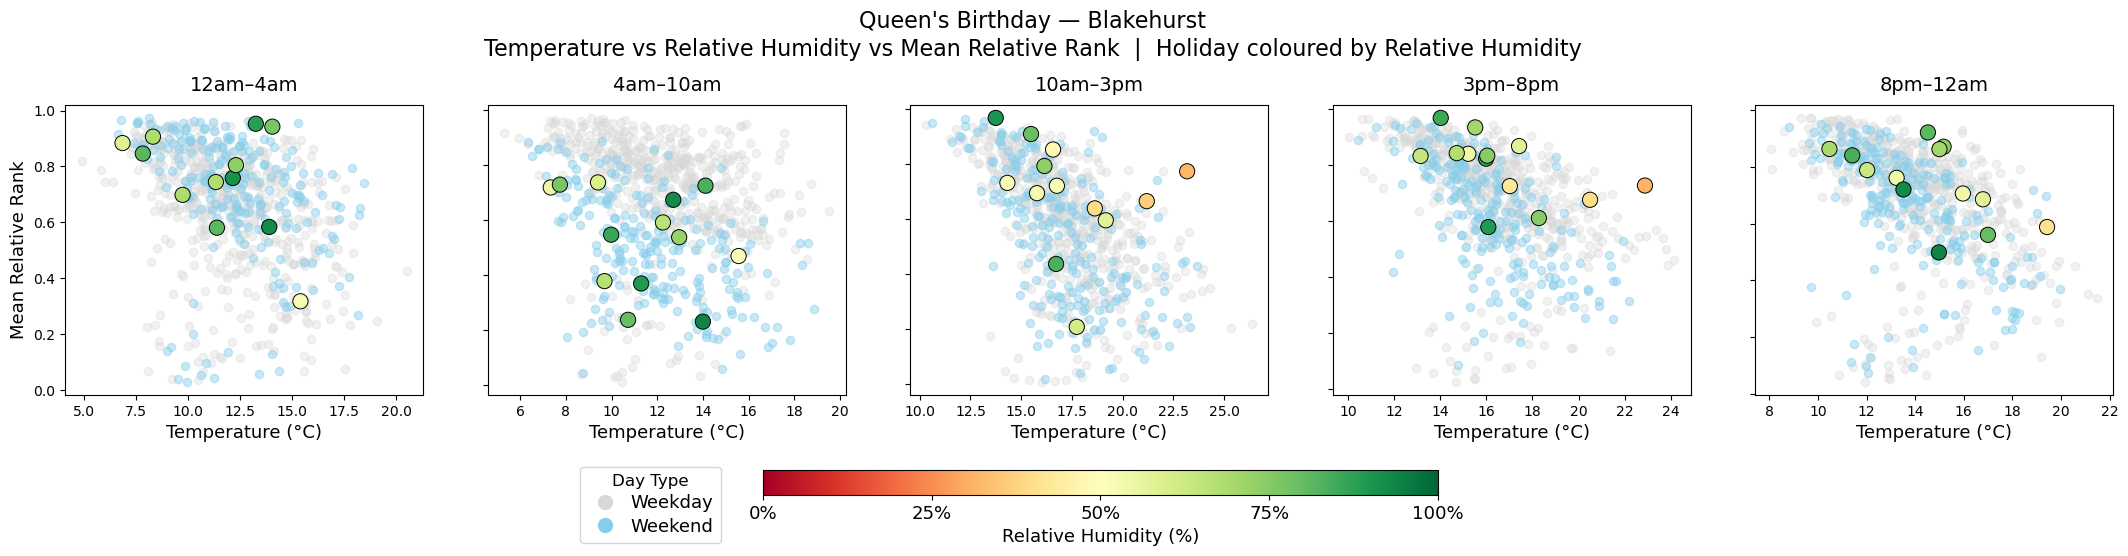

In [42]:
plot_rh_scatter_for_station(
    demand_rank,
    weather_rank,
    "BLAKE",
    "Queen's Birthday"
)

### Batch looping and saving

In [43]:
def batch_plot_rh_scatter_all_stations(demand_rank, weather_rank):
    import os

    base_dir = "/home/565/pv3484/aus_substation_electricity/data/figures/multi_dimension_mean_rank/relative_humidity"

    holiday_groups = sorted(demand_rank["holiday_group"].unique())
    station_codes = sorted(demand_rank["station_code"].unique())

    for station_code in station_codes:
        print(f"\n=== Station: {station_code} ===")

        for holiday_name in holiday_groups:
            print(f"  Plotting: {holiday_name}...")

            fig, missing = plot_rh_scatter_for_station(
                demand_rank,
                weather_rank,
                station_code,
                holiday_name
            )

            if fig is None:
                print(f"    SKIPPED — {missing}")
                continue

            holiday_folder = os.path.join(base_dir, holiday_name.replace(" ", "_"))
            os.makedirs(holiday_folder, exist_ok=True)

            filename = f"{station_code}_{holiday_name.replace(' ', '_')}_dewpoint.png"
            save_path = os.path.join(holiday_folder, filename)
            fig.savefig(save_path, dpi=150, bbox_inches="tight")
            plt.close(fig)
            print(f"    Saved → {save_path}")

In [44]:
batch_plot_rh_scatter_all_stations(demand_rank, weather_rank)


=== Station: ADAMS ===
  Plotting: ANZAC Day...
    Saved → /home/565/pv3484/aus_substation_electricity/data/figures/multi_dimension_mean_rank/relative_humidity/ANZAC_Day/ADAMS_ANZAC_Day_dewpoint.png
  Plotting: Australia Day...
    Saved → /home/565/pv3484/aus_substation_electricity/data/figures/multi_dimension_mean_rank/relative_humidity/Australia_Day/ADAMS_Australia_Day_dewpoint.png
  Plotting: Boxing Day...
    SKIPPED — ['NO WEATHER DATA']
  Plotting: Christmas Day...
    SKIPPED — ['NO WEATHER DATA']
  Plotting: Christmas and Boxing Day...
    Saved → /home/565/pv3484/aus_substation_electricity/data/figures/multi_dimension_mean_rank/relative_humidity/Christmas_and_Boxing_Day/ADAMS_Christmas_and_Boxing_Day_dewpoint.png
  Plotting: Easter Long Weekend...
    Saved → /home/565/pv3484/aus_substation_electricity/data/figures/multi_dimension_mean_rank/relative_humidity/Easter_Long_Weekend/ADAMS_Easter_Long_Weekend_dewpoint.png
  Plotting: Easter Monday...
    SKIPPED — ['NO WEATHER DA